# Positron Angle Finder

This notebook trains a `PositronAngleModel` to predict the emission angle of positrons.
It uses the standardized `GraphRecord` and `GraphGroupDataset` infrastructure.

**Features**: `coord`, `z`, `view`, `energy` (4D).
**Filtering**: Groups must contain at least 2 MIP hits (Positron or Electron).
**Loss**: `1 - (u_pred . u_true)` (Direct cosine alignment).


In [1]:
import sys, os
import glob
import re
import math
from typing import List, Optional, Tuple, Dict, Any, Sequence
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch.nn.utils import clip_grad_norm_

PROJECT_ROOT = "/mnt/c/Users/obbee/research/notebooks/ML"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
    os.environ["PYTHONPATH"] = PROJECT_ROOT + os.pathsep + os.environ.get("PYTHONPATH", "")

from graph_data.utils import GraphRecord, GraphGroupDataset
from graph_data.models import PositronAngleModel


/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def spherical_to_cartesian_numpy(theta, phi):
    """Converts spherical (theta, phi) to unit vector (x, y, z) [Numpy]."""
    sin_theta = np.sin(theta)
    x = sin_theta * np.cos(phi)
    y = sin_theta * np.sin(phi)
    z = np.cos(theta)
    return np.array([x, y, z], dtype=np.float32)

def compute_component_errors(pred_vec, target_vec):
    """
    Computes Absolute Error for Theta and Phi in degrees per sample.
    Returns: (theta_errs, phi_errs) as 1D tensors [Batch]
    """
    # Ensure normalized
    pred_vec = F.normalize(pred_vec, p=2, dim=1)
    target_vec = F.normalize(target_vec, p=2, dim=1)

    # Convert to Theta/Phi
    # z = cos(theta) -> theta = acos(z)
    pred_theta = torch.acos(pred_vec[:, 2].clamp(-1, 1))
    target_theta = torch.acos(target_vec[:, 2].clamp(-1, 1))
    
    # phi = atan2(y, x)
    pred_phi = torch.atan2(pred_vec[:, 1], pred_vec[:, 0])
    target_phi = torch.atan2(target_vec[:, 1], target_vec[:, 0])

    # 1. Theta Error (Simple absolute difference)
    theta_err = torch.abs(pred_theta - target_theta)
    
    # 2. Phi Error (Circular difference)
    phi_diff = pred_phi - target_phi
    phi_err = torch.abs(torch.atan2(torch.sin(phi_diff), torch.cos(phi_diff)))

    return torch.rad2deg(theta_err), torch.rad2deg(phi_err)


In [3]:
def load_positron_groups(
    npy_files: List[str],
    verbose: bool = True,
    limit_groups: Optional[int] = None
) -> List[GraphRecord]:
    """
    Loads groups containing positrons/electrons (MIPs) and extracts true angle (theta, phi).
    Filters for groups with >= 2 MIP hits.
    """
    records = []
    
    if verbose:
        print(f"Found {len(npy_files)} hit files. Starting processing...")
    
    def extract_index(fname):
        match = re.search(r'hits_batch_(\d+)\.npy', fname)
        return int(match.group(1)) if match else -1
    
    paths = sorted(npy_files, key=extract_index)
    
    for path in tqdm(paths, desc="Processing Files", disable=not verbose):

        if limit_groups and len(records) >= limit_groups:
            break

        try:
            chunk_data = np.load(path, allow_pickle=True)
            batch_idx = extract_index(path)
            info_path = path.replace(f"hits_batch_{batch_idx}.npy", f"group_info_batch_{batch_idx}.npy")
            info_data = np.load(info_path, allow_pickle=True)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            continue
            
        for group, g_info in zip(chunk_data, info_data):
            if limit_groups and len(records) >= limit_groups:
                break

            if len(group) < 2:
                continue
                
            group = np.array(group)
            
            # Extract PDG mask (index 4)
            hit_masks = group[:, 4].astype(int)
            
            # MIP Check: Positron (4) or Electron (8)
            is_mip = (hit_masks & 12) != 0
            
            # Filter: Must have >= 2 MIP hits
            if np.sum(is_mip) < 2:
                continue
            
            # Extract features (4D: coord, z, view, energy)
            coord = group[:, 0].astype(np.float32)
            z_pos = group[:, 1].astype(np.float32)
            view_flag = group[:, 2].astype(np.float32)
            energy = group[:, 3].astype(np.float32)
            
            # Extract Angles from g_info (index 9: theta, 10: phi)
            theta = g_info[9]
            phi = g_info[10]
            
            if theta == -1000 or phi == -1000:
                continue

            # Compute true unit vector [x, y, z]
            unit_vec = spherical_to_cartesian_numpy(theta, phi)
            
            record_event_id = int(g_info[11])
            
            records.append(GraphRecord(
                coord=coord,
                z=z_pos,
                view=view_flag,
                energy=energy,
                true_angle_vector=unit_vec,
                event_id=record_event_id,
                group_id=len(records),
                pred_pion_stop=[g_info[3], g_info[4], g_info[5]],
            ))
            
    if verbose:
        print(f"Loaded {len(records)} positron groups.")

    return records


In [4]:
def angular_loss(pred_unit_vec, target_unit_vec):
    """
    Loss = 1 - (u_pred . u_true)
    target_unit_vec: [Batch, 3] (x, y, z) - computed during loading
    """
    # Target is already a unit vector
    pred_unit_vec = F.normalize(pred_unit_vec, p=2, dim=1)
    dot_product = torch.sum(pred_unit_vec * target_unit_vec, dim=1)
    loss = 1.0 - (dot_product)
    return loss.mean()

In [5]:
def plot_training_results(train_losses, val_losses, train_theta_errs, val_theta_errs, train_phi_errs, val_phi_errs):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    ax[0].plot(train_losses, label='Train Loss')
    ax[0].plot(val_losses, label='Val Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Loss Curves')
    ax[0].legend()
    ax[0].grid(True)
    
    ax[1].plot(train_theta_errs, label='Train Theta Err')
    ax[1].plot(val_theta_errs, label='Val Theta Err')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Abs Error (deg)')
    ax[1].set_title('Theta Error')
    ax[1].legend()
    ax[1].grid(True)

    ax[2].plot(train_phi_errs, label='Train Phi Err')
    ax[2].plot(val_phi_errs, label='Val Phi Err')
    ax[2].set_xlabel('Epoch')
    ax[2].set_ylabel('Abs Error (deg)')
    ax[2].set_title('Phi Error')
    ax[2].legend()
    ax[2].grid(True)

    plt.show()

def plot_error_hists(theta_errs, phi_errs):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    ax[0].hist(theta_errs, bins=50, alpha=0.7, color='purple')
    ax[0].set_xlabel('Theta Error (deg)')
    ax[0].set_title('Validation Theta Error Distribution')
    ax[0].grid(True, alpha=0.3)

    ax[1].hist(phi_errs, bins=50, alpha=0.7, color='orange')
    ax[1].set_xlabel('Phi Error (deg)')
    ax[1].set_title('Validation Phi Error Distribution')
    ax[1].grid(True, alpha=0.3)
    
    plt.show()

In [6]:
def train_positron_angle(
    model,
    train_groups,
    val_groups,
    device='cuda',
    batch_size=128,
    epochs=20,
    lr=1e-3,
    weight_decay=1e-5
):
    # Standard GraphGroupDataset
    train_dataset = GraphGroupDataset(train_groups)
    val_dataset = GraphGroupDataset(val_groups)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    device_obj = torch.device(device if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device_obj}")
    
    model = model.to(device_obj)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    train_losses, val_losses = [], []
    train_theta_means, val_theta_means = [], []
    train_phi_means, val_phi_means = [], []
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_theta_err = 0.0
        total_phi_err = 0.0
        count = 0
        
        for batch in train_loader:
            batch = batch.to(device_obj)
            optimizer.zero_grad()
            
            # Forward
            pred = model(batch)
            
            # Retrieve target from y_angle_vector
            target = batch.y_angle_vector.squeeze(1)
            
            loss = angular_loss(pred, target)
            loss.backward()
            clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            batch_size_actual = pred.size(0)
            total_loss += loss * batch_size_actual
            
            with torch.no_grad():
                # Metric per batch
                theta_errs, phi_errs = compute_component_errors(pred, target)
                
                total_theta_err += theta_errs.sum()
                total_phi_err += phi_errs.sum()
                count += batch_size_actual
                
        avg_train_loss = total_loss.item() / count
        avg_train_theta = total_theta_err.item() / count
        avg_train_phi = total_phi_err.item() / count
        
        # Validation
        model.train()
        val_loss = 0.0
        val_theta_err = 0.0
        val_phi_err = 0.0
        val_count = 0
        
        all_val_theta_errs = []
        all_val_phi_errs = []
        
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device_obj)
                pred = model(batch)
                target = batch.y_angle_vector.squeeze(1)
                
                loss = angular_loss(pred, target)
                val_loss += loss * pred.size(0)
                
                # Metrics
                theta_errs, phi_errs = compute_component_errors(pred, target)
                
                val_theta_err += theta_errs.sum()
                val_phi_err += phi_errs.sum()
                val_count += pred.size(0)
                
                # Accumulate for histograms
                all_val_theta_errs.extend(theta_errs.cpu().numpy())
                all_val_phi_errs.extend(phi_errs.cpu().numpy())
        
        avg_val_loss = val_loss.item() / val_count
        avg_val_theta = val_theta_err.item() / val_count
        avg_val_phi = val_phi_err.item() / val_count
        
        scheduler.step(avg_val_loss)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        train_theta_means.append(avg_train_theta)
        val_theta_means.append(avg_val_theta)
        
        train_phi_means.append(avg_train_phi)
        val_phi_means.append(avg_val_phi)
        
        print(f"Epoch {epoch}: Train Loss={avg_train_loss:.4f}, Theta={avg_train_theta:.1f}, Phi={avg_train_phi:.1f} | Val Loss={avg_val_loss:.4f}, Theta={avg_val_theta:.1f}, Phi={avg_val_phi:.1f}")
        
    plot_training_results(
        train_losses, val_losses, 
        train_theta_means, val_theta_means, 
        train_phi_means, val_phi_means
    )
    plot_error_hists(all_val_theta_errs, all_val_phi_errs)
    return model

In [7]:
data_dir = "npy_data"
npy_files = glob.glob(os.path.join(data_dir, "hits_batch_*.npy"))

# Load groups
groups = load_positron_groups(npy_files, limit_groups=100000)

# Split Train/Val
rng = np.random.default_rng(42)
rng.shuffle(groups)

split_idx = int(0.85 * len(groups))
train_groups = groups[:split_idx]
val_groups = groups[split_idx:]

print(f"Train: {len(train_groups)}, Val: {len(val_groups)}")

Found 289 hit files. Starting processing...


Processing Files:   0%|          | 0/289 [00:00<?, ?it/s]

Processing Files:  10%|█         | 30/289 [06:33<56:38, 13.12s/it]  

Loaded 100000 positron groups.
Train: 85000, Val: 15000


In [12]:
model = PositronAngleModel(in_channels=4, hidden=150, heads=3, layers=2, dropout=0.05)

Using device: cuda
Epoch 1: Train Loss=0.7069, Theta=53.0, Phi=84.3 | Val Loss=0.4816, Theta=38.1, Phi=68.6
Epoch 2: Train Loss=0.3272, Theta=24.1, Phi=51.8 | Val Loss=0.2410, Theta=18.9, Phi=42.2
Epoch 3: Train Loss=0.1804, Theta=15.1, Phi=34.0 | Val Loss=0.1640, Theta=14.7, Phi=30.6
Epoch 4: Train Loss=0.1354, Theta=12.3, Phi=27.9 | Val Loss=0.1184, Theta=10.6, Phi=24.8
Epoch 5: Train Loss=0.1133, Theta=10.9, Phi=24.4 | Val Loss=0.1078, Theta=9.7, Phi=23.4
Epoch 6: Train Loss=0.1030, Theta=10.0, Phi=22.5 | Val Loss=0.1064, Theta=9.6, Phi=21.4
Epoch 7: Train Loss=0.0955, Theta=9.5, Phi=21.2 | Val Loss=0.0895, Theta=8.4, Phi=19.6
Epoch 8: Train Loss=0.0916, Theta=9.3, Phi=20.6 | Val Loss=0.0985, Theta=9.3, Phi=20.9
Epoch 9: Train Loss=0.0879, Theta=9.1, Phi=20.0 | Val Loss=0.0916, Theta=9.1, Phi=20.1
Epoch 10: Train Loss=0.0833, Theta=8.8, Phi=19.3 | Val Loss=0.0868, Theta=9.3, Phi=20.1
Epoch 11: Train Loss=0.0797, Theta=8.5, Phi=18.8 | Val Loss=0.0999, Theta=9.4, Phi=21.4
Epoch 12: Tr

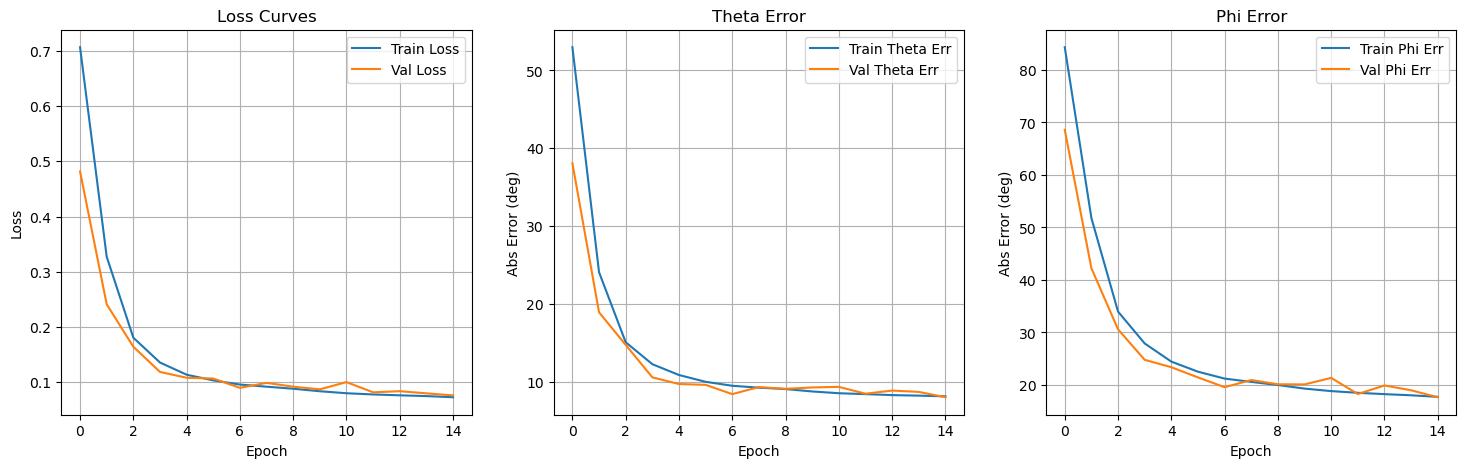

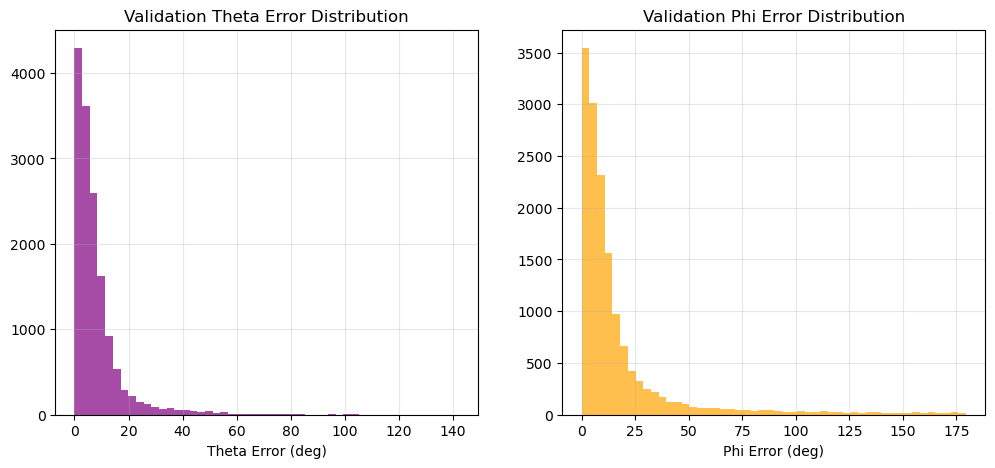

In [13]:
# Train
model = train_positron_angle(
    model, 
    train_groups, 
    val_groups,
    batch_size=16, 
    epochs=15, 
    lr=1e-4
)